# Deteksi Website Phishing: Replikasi + Optimasi XGBoost
**Paper Acuan:** Shaukat et al. (2023) - Sensors, MDPI (Scopus Q1)

**Alur:**
1. Load & Preprocessing Dataset
2. Exploratory Data Analysis (EDA)
3. Replikasi: Random Forest (Baseline)
4. Usulan: XGBoost + Hyperparameter Tuning (GridSearchCV)
5. Perbandingan & Visualisasi

In [18]:
# ============================================================
# CELL 1: INSTALL & IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
import joblib

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


In [19]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================
# Jika pakai Google Colab, upload file dulu:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/dataset_phishing.csv')

print('=== INFORMASI DATASET ===')
print(f'Total data: {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'\nDistribusi Label:')
print(df['status'].value_counts())
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplikat: {df.duplicated().sum()}')
df.head(3)

=== INFORMASI DATASET ===
Total data: 11430 baris, 89 kolom

Distribusi Label:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Missing values: 0
Duplikat: 0


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


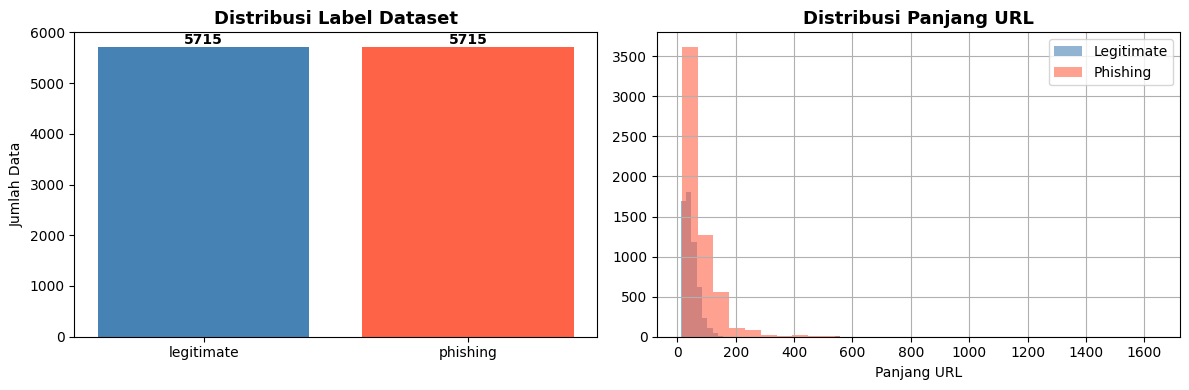

Grafik EDA tersimpan!


In [20]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi label
label_counts = df['status'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribusi Label Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Distribusi panjang URL
df_plot = df.copy()
df_plot['status_num'] = df_plot['status'].map({'legitimate': 0, 'phishing': 1})
df[df['status']=='legitimate']['length_url'].hist(ax=axes[1], alpha=0.6, label='Legitimate', color='steelblue', bins=30)
df[df['status']=='phishing']['length_url'].hist(ax=axes[1], alpha=0.6, label='Phishing', color='tomato', bins=30)
axes[1].set_title('Distribusi Panjang URL', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Panjang URL')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik EDA tersimpan!')

In [21]:
# ============================================================
# CELL 4: PREPROCESSING
# ============================================================
df_clean = df.drop_duplicates().dropna().copy()

# Hapus kolom URL (teks, tidak bisa dibaca ML)
if 'url' in df_clean.columns:
    df_clean = df_clean.drop(columns=['url'])

# Pisahkan fitur dan label
X = df_clean.drop(columns=['status'])
y = df_clean['status']

# Encode label: legitimate=0, phishing=1
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(f'Mapping label: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}')

# Feature Selection: ambil 30 fitur terbaik
# (menyesuaikan dengan paper Shaukat et al. yang pakai 22 fitur)
selector = SelectKBest(score_func=f_classif, k=30)
X_selected = selector.fit_transform(X, y)
selected_feature_names = X.columns[selector.get_support()].tolist()

print(f'\nTotal fitur asli: {X.shape[1]}')
print(f'Fitur terpilih (top 30): {len(selected_feature_names)}')
print(f'\nFitur terpilih: {selected_feature_names}')

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nData Training: {X_train.shape[0]} baris')
print(f'Data Testing: {X_test.shape[0]} baris')

Mapping label: {'legitimate': np.int64(0), 'phishing': np.int64(1)}

Total fitur asli: 87
Fitur terpilih (top 30): 30

Fitur terpilih: ['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_qm', 'nb_eq', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain', 'prefix_suffix', 'length_words_raw', 'shortest_word_host', 'longest_words_raw', 'longest_word_path', 'avg_word_host', 'avg_word_path', 'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks', 'links_in_tags', 'ratio_intMedia', 'safe_anchor', 'empty_title', 'domain_in_title', 'domain_with_copyright', 'domain_age', 'google_index', 'page_rank']

Data Training: 9144 baris
Data Testing: 2286 baris


In [22]:
# ============================================================
# CELL 5: REPLIKASI - RANDOM FOREST (BASELINE)
# ============================================================
print('=== REPLIKASI: RANDOM FOREST (BASELINE) ===')
print('Mereplikasi metode dari Shaukat et al. (2023)...')

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

# Hitung semua metrik
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

print(f'\nHasil Replikasi Random Forest:')
print(f'  Accuracy  : {acc_rf*100:.2f}%')
print(f'  Precision : {prec_rf*100:.2f}%')
print(f'  Recall    : {rec_rf*100:.2f}%')
print(f'  F1-Score  : {f1_rf*100:.2f}%')
print(f'  AUC-ROC   : {auc_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

=== REPLIKASI: RANDOM FOREST (BASELINE) ===
Mereplikasi metode dari Shaukat et al. (2023)...

Hasil Replikasi Random Forest:
  Accuracy  : 96.19%
  Precision : 95.75%
  Recall    : 96.68%
  F1-Score  : 96.21%
  AUC-ROC   : 0.9924

Classification Report:
              precision    recall  f1-score   support

  legitimate       0.97      0.96      0.96      1143
    phishing       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



In [24]:
# ============================================================
# CELL 6: USULAN - XGBOOST + HYPERPARAMETER TUNING
# ============================================================
print('=== METODE USULAN: XGBOOST + GRIDSEARCHCV ===')
print('Melakukan hyperparameter tuning... (butuh 2-5 menit)')

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

# Parameter grid yang lebih komprehensif
param_grid = {
    'n_estimators'  : [100, 300, 500],
    'max_depth'     : [3, 5, 7, 9],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Hitung semua metrik
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
auc_xgb  = roc_auc_score(y_test, y_prob_xgb)

print(f'\nParameter Terbaik: {grid_search.best_params_}')
print(f'\nHasil XGBoost Optimized:')
print(f'  Accuracy  : {acc_xgb*100:.2f}%')
print(f'  Precision : {prec_xgb*100:.2f}%')
print(f'  Recall    : {rec_xgb*100:.2f}%')
print(f'  F1-Score  : {f1_xgb*100:.2f}%')
print(f'  AUC-ROC   : {auc_xgb:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=encoder.classes_))

=== METODE USULAN: XGBOOST + GRIDSEARCHCV ===
Melakukan hyperparameter tuning... (butuh 2-5 menit)
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Parameter Terbaik: {'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 1.0}

Hasil XGBoost Optimized:
  Accuracy  : 96.46%
  Precision : 95.70%
  Recall    : 97.29%
  F1-Score  : 96.49%
  AUC-ROC   : 0.9925

Classification Report:
              precision    recall  f1-score   support

  legitimate       0.97      0.96      0.96      1143
    phishing       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



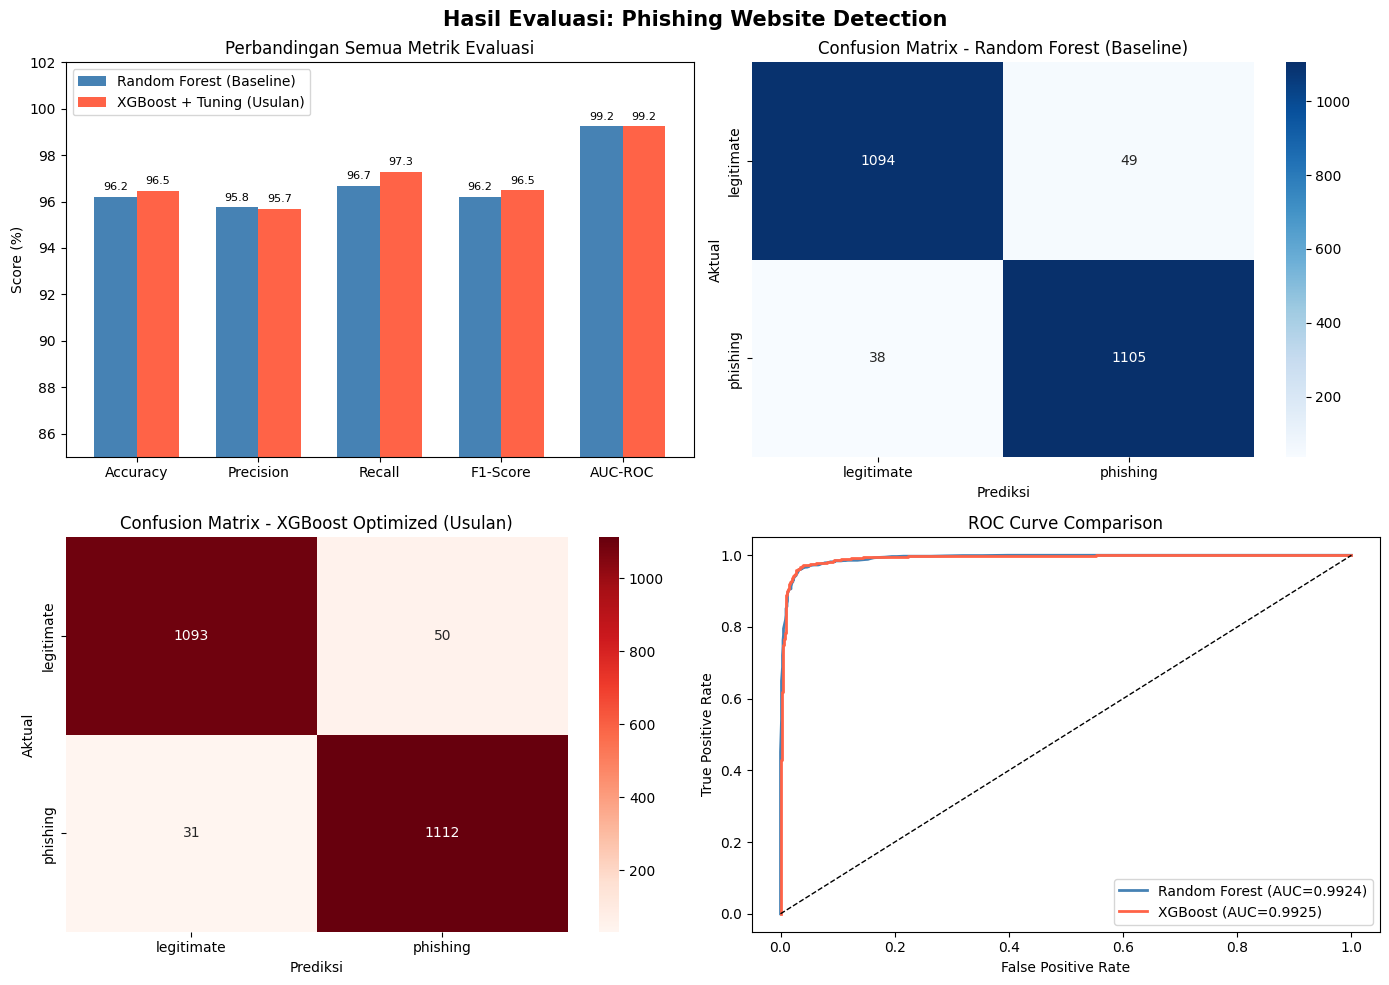

Grafik tersimpan sebagai hasil_evaluasi_lengkap.png


In [25]:
# ============================================================
# CELL 7: VISUALISASI LENGKAP (4 GRAFIK SEKALIGUS)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hasil Evaluasi: Phishing Website Detection', fontsize=15, fontweight='bold')

# --- GRAFIK 1: Perbandingan Akurasi ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
rf_scores  = [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf]
xgb_scores = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_xgb]

x = np.arange(len(metrics))
width = 0.35
bars1 = axes[0,0].bar(x - width/2, [s*100 for s in rf_scores], width, label='Random Forest (Baseline)', color='steelblue')
bars2 = axes[0,0].bar(x + width/2, [s*100 for s in xgb_scores], width, label='XGBoost + Tuning (Usulan)', color='tomato')
axes[0,0].set_ylabel('Score (%)')
axes[0,0].set_title('Perbandingan Semua Metrik Evaluasi')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics)
axes[0,0].set_ylim(85, 102)
axes[0,0].legend()
for bar in bars1:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# --- GRAFIK 2: Confusion Matrix Random Forest ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[0,1].set_title('Confusion Matrix - Random Forest (Baseline)')
axes[0,1].set_ylabel('Aktual')
axes[0,1].set_xlabel('Prediksi')

# --- GRAFIK 3: Confusion Matrix XGBoost ---
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1,0],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[1,0].set_title('Confusion Matrix - XGBoost Optimized (Usulan)')
axes[1,0].set_ylabel('Aktual')
axes[1,0].set_xlabel('Prediksi')

# --- GRAFIK 4: ROC Curve ---
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axes[1,1].plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC={auc_rf:.4f})',  color='steelblue', lw=2)
axes[1,1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.4f})', color='tomato', lw=2)
axes[1,1].plot([0,1],[0,1], 'k--', lw=1)
axes[1,1].set_title('ROC Curve Comparison')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('hasil_evaluasi_lengkap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan sebagai hasil_evaluasi_lengkap.png')

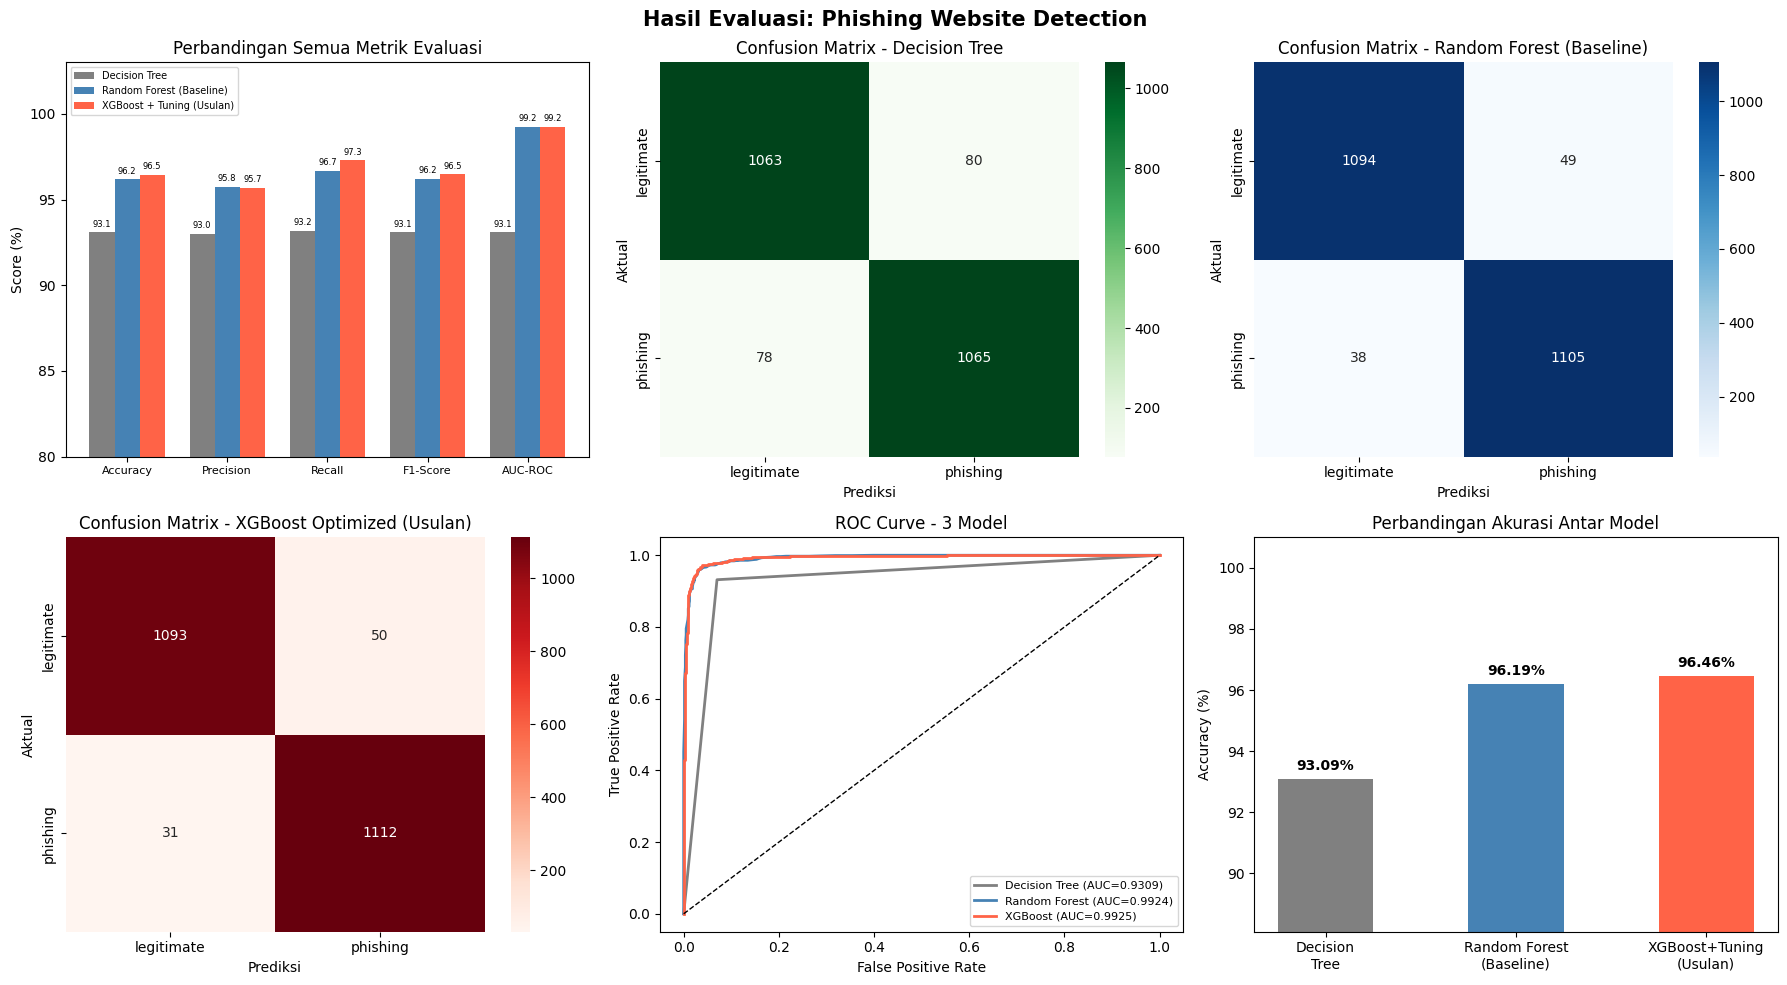

Grafik tersimpan!


In [28]:
# ============================================================
# CELL 8: VISUALISASI LENGKAP (UPDATE - 3 MODEL)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hasil Evaluasi: Phishing Website Detection', fontsize=15, fontweight='bold')

# --- GRAFIK 1: Perbandingan Semua Metrik ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
dt_scores  = [acc_dt,  prec_dt,  rec_dt,  f1_dt,  auc_dt]
rf_scores  = [acc_rf,  prec_rf,  rec_rf,  f1_rf,  auc_rf]
xgb_scores = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_xgb]

x = np.arange(len(metrics))
width = 0.25
bars1 = axes[0,0].bar(x - width, [s*100 for s in dt_scores],  width, label='Decision Tree',            color='gray')
bars2 = axes[0,0].bar(x,         [s*100 for s in rf_scores],  width, label='Random Forest (Baseline)', color='steelblue')
bars3 = axes[0,0].bar(x + width, [s*100 for s in xgb_scores], width, label='XGBoost + Tuning (Usulan)',color='tomato')
axes[0,0].set_ylabel('Score (%)')
axes[0,0].set_title('Perbandingan Semua Metrik Evaluasi')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics, fontsize=8)
axes[0,0].set_ylim(80, 103)
axes[0,0].legend(fontsize=7)
for bar in [*bars1, *bars2, *bars3]:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=6)

# --- GRAFIK 2: Confusion Matrix Decision Tree ---
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0,1],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[0,1].set_title('Confusion Matrix - Decision Tree')
axes[0,1].set_ylabel('Aktual')
axes[0,1].set_xlabel('Prediksi')

# --- GRAFIK 3: Confusion Matrix Random Forest ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[0,2].set_title('Confusion Matrix - Random Forest (Baseline)')
axes[0,2].set_ylabel('Aktual')
axes[0,2].set_xlabel('Prediksi')

# --- GRAFIK 4: Confusion Matrix XGBoost ---
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1,0],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[1,0].set_title('Confusion Matrix - XGBoost Optimized (Usulan)')
axes[1,0].set_ylabel('Aktual')
axes[1,0].set_xlabel('Prediksi')

# --- GRAFIK 5: ROC Curve 3 Model ---
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_prob_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axes[1,1].plot(fpr_dt,  tpr_dt,  label=f'Decision Tree (AUC={auc_dt:.4f})',  color='gray',      lw=2)
axes[1,1].plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC={auc_rf:.4f})',  color='steelblue', lw=2)
axes[1,1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.4f})',      color='tomato',    lw=2)
axes[1,1].plot([0,1],[0,1], 'k--', lw=1)
axes[1,1].set_title('ROC Curve - 3 Model')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend(fontsize=8)

# --- GRAFIK 6: Bar Chart Akurasi Simpel ---
model_names = ['Decision\nTree', 'Random Forest\n(Baseline)', 'XGBoost+Tuning\n(Usulan)']
accuracies  = [acc_dt*100, acc_rf*100, acc_xgb*100]
colors      = ['gray', 'steelblue', 'tomato']
bars = axes[1,2].bar(model_names, accuracies, color=colors, width=0.5)
axes[1,2].set_ylim(min(accuracies)-5, 101)
axes[1,2].set_ylabel('Accuracy (%)')
axes[1,2].set_title('Perbandingan Akurasi Antar Model')
for bar in bars:
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f'{bar.get_height():.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('hasil_evaluasi_lengkap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan!')

In [30]:
# ============================================================
# CELL 9: TABEL PERBANDINGAN AKHIR (UPDATE - 3 MODEL)
# ============================================================
tabel = pd.DataFrame({
    'Metrik'                    : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Decision Tree'             : [f'{acc_dt*100:.2f}%',  f'{prec_dt*100:.2f}%',
                                   f'{rec_dt*100:.2f}%',  f'{f1_dt*100:.2f}%',  f'{auc_dt:.4f}'],
    'Random Forest (Baseline)'  : [f'{acc_rf*100:.2f}%',  f'{prec_rf*100:.2f}%',
                                   f'{rec_rf*100:.2f}%',  f'{f1_rf*100:.2f}%',  f'{auc_rf:.4f}'],
    'XGBoost+Tuning (Usulan)'   : [f'{acc_xgb*100:.2f}%', f'{prec_xgb*100:.2f}%',
                                   f'{rec_xgb*100:.2f}%', f'{f1_xgb*100:.2f}%', f'{auc_xgb:.4f}'],
})

print('\n=== TABEL PERBANDINGAN AKHIR ===')
print(tabel.to_string(index=False))
print(f'\nParameter XGBoost terbaik: {grid_search.best_params_}')


=== TABEL PERBANDINGAN AKHIR ===
   Metrik Decision Tree Random Forest (Baseline) XGBoost+Tuning (Usulan)
 Accuracy        93.09%                   96.19%                  96.46%
Precision        93.01%                   95.75%                  95.70%
   Recall        93.18%                   96.68%                  97.29%
 F1-Score        93.09%                   96.21%                  96.49%
  AUC-ROC        0.9309                   0.9924                  0.9925

Parameter XGBoost terbaik: {'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 1.0}


In [31]:
# ============================================================
# CELL 10: SIMPAN MODEL (untuk folder 06_Model)
# ============================================================
joblib.dump(best_xgb, 'xgboost_phishing_model.pkl')
joblib.dump(model_rf, 'randomforest_baseline.pkl')
joblib.dump(encoder, 'label_encoder.pkl')
joblib.dump(selector, 'feature_selector.pkl')

print('Model tersimpan:')
print('  xgboost_phishing_model.pkl  -> masuk folder 06_Model/')
print('  randomforest_baseline.pkl   -> masuk folder 06_Model/')
print('  label_encoder.pkl           -> masuk folder 06_Model/')
print('  feature_selector.pkl        -> masuk folder 06_Model/')
print('\nSelesai! Semua file siap dikumpulkan.')
# Download semua file model ke laptop kamu
from google.colab import files

files.download('xgboost_phishing_model.pkl')
files.download('randomforest_baseline.pkl')
files.download('label_encoder.pkl')
files.download('feature_selector.pkl')
files.download('hasil_evaluasi_lengkap.png')
files.download('eda_distribusi.png')

Model tersimpan:
  xgboost_phishing_model.pkl  -> masuk folder 06_Model/
  randomforest_baseline.pkl   -> masuk folder 06_Model/
  label_encoder.pkl           -> masuk folder 06_Model/
  feature_selector.pkl        -> masuk folder 06_Model/

Selesai! Semua file siap dikumpulkan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>